# uq-pet — pipeline walkthrough

Is **LLM uncertainty quantification a good criterion for choosing training data**, compared to random choice? This notebook runs that experiment on the [PET dataset](https://github.com/patriziobellan86/PETv1.1) (process-extraction NER, 417 sentences, 15 BIO tags) end-to-end, using the `uq_pet` package.

```text
PET NER dataset
├── 80% experiment pool (333 sentences)
│     │  LLM repeated sampling (llama-3-8b, K=5, temp 0.7) → uncertainty score per sentence
│     ├── top-N% most uncertain  → fine-tune transformer → evaluate
│     └── random N%              → fine-tune transformer → evaluate
└── 20% held-out test (84 sentences) ──────────────────────→ used for both evaluations
```

Every heavy stage is **cache-aware**: LLM sampling resumes from `results/llm_scores/` and the training grid skips cells already recorded in `results/experiment_runs.jsonl`. With the shipped caches a top-to-bottom run takes a couple of minutes — the only cell that does real work every time is the mini training demo.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, Markdown

from uq_pet.config import FIGURES_DIR, ExperimentConfig
from uq_pet.data import sentence_key, split_pool_test, tag_ids_to_labels

cfg = ExperimentConfig()
cfg

ExperimentConfig(budgets=[10, 25, 50, 100], strategies=['random', 'uncertainty:mean_token_entropy', 'uncertainty:sequence_entropy', 'uncertainty:jaccard_distance'], repeats=5, llm=LLMScoreConfig(model='meta-llama/llama-3-8b-instruct', num_samples=5, temperature=0.7, max_tokens=1500, seed=3407, max_concurrency=8, max_retries=3), train=TrainConfig(checkpoint='distilbert-base-cased', epochs=20, batch_size=8, learning_rate=5e-05, weight_decay=0.01, warmup_fraction=0.1, max_length=256))

## Data

`split_pool_test` downloads PETv1.1 (cached by HF `datasets`) and makes the deterministic 80/20 pool/test split (seed 3407). The pool is what the LLM scores and what training subsets are drawn from; the test split is only ever used for evaluation.

In [2]:
pool, test = split_pool_test(seed=cfg.llm.seed)
by_key = {sentence_key(ex): ex for ex in pool}
print(f"pool: {len(pool)} sentences   test: {len(test)} sentences")

example = pool[0]
pd.DataFrame({"token": example["tokens"], "tag": tag_ids_to_labels(example["ner-tags"])}).T

pool: 333 sentences   test: 84 sentences


,0,1,2,3,4,5,6
token,Then,",",an,assessment,is,performed,.
tag,O,O,B-Activity Data,I-Activity Data,O,B-Activity,O


In [3]:
from uq_pet.viz import plot_ner_heatmap

plot_ner_heatmap(pool)

## Stage 1 — LLM repeated sampling (cache-aware)

Each pool sentence is tagged K=5 times by `meta-llama/llama-3-8b-instruct` at temperature 0.7 (via OpenRouter, ~1,665 calls on a cold cache). Raw responses and parsed tag sequences are appended to a JSONL cache; already-scored sentences are skipped, so this cell is a no-op when the cache is complete. A cold run needs `OPENROUTER_API_KEY` in `.env`.

Uncertainty metrics are **not** stored in the cache — they are recomputed from `parsed_samples`, so metrics, budgets and repeats can be swept without new API calls.

In [4]:
from uq_pet.llm_scoring import load_cache, score_pool

cache = load_cache(cfg.llm.cache_path())
missing = [ex for ex in pool if sentence_key(ex) not in cache]
print(f"cache: {len(cache)} sentences at {cfg.llm.cache_path()} ({len(missing)} missing)")

if missing:
    cache = await score_pool(cfg.llm, pool)

cache: 333 sentences at results/llm_scores/meta-llama_llama-3-8b-instruct_k5_t0.7_seed3407.jsonl (0 missing)


One cached record: the gold tags next to the K sampled tag sequences. Positions where the samples disagree are exactly what the uncertainty metrics quantify.

In [5]:
record = cache[sentence_key(pool[0])]
print(" ".join(record["tokens"]))
pd.DataFrame(
    [record["gt_tags"], *record["parsed_samples"]],
    index=["gold", *[f"sample {i + 1}" for i in range(len(record["parsed_samples"]))]],
    columns=record["tokens"],
)

Then , an assessment is performed .


,Then,",",an,assessment,is,performed,.
gold,O,O,B-Activity Data,I-Activity Data,O,B-Activity,O
sample 1,B-Actor,O,O,B-Activity,I-Activity,I-Activity,O
sample 2,B-Actor,O,B-Actor,B-Activity,I-Activity,I-Activity,O
sample 3,B-Actor,O,B-Actor,B-Activity,B-Activity,I-Activity,O
sample 4,B-Actor,O,B-Actor,B-Activity,I-Activity,I-Activity,O
sample 5,B-Actor,O,B-Actor,B-Activity,I-Activity,B-Activity,O


## Stage 2 — uncertainty metrics

The metric is itself an experimental variable: everything registered in `uq_pet.uncertainty.METRICS` maps the K tag sequences of a sentence to a scalar (higher = more uncertain).

In [6]:
from uq_pet.uncertainty import METRICS

scores = pd.DataFrame({
    name: {key: fn(rec["parsed_samples"]) for key, rec in cache.items()}
    for name, fn in METRICS.items()
})
scores.describe().round(3)

,sequence_entropy,mean_token_entropy,max_token_entropy,variation_ratio,jaccard_distance
count,333.000,333.000,333.000,333.000,333.000
mean,1.992,0.533,1.475,0.178,0.414
std,0.556,0.256,0.478,0.089,0.163
min,-0.000,0.000,-0.000,0.000,0.000
25%,1.922,0.356,1.371,0.117,0.318
50%,2.322,0.537,1.522,0.178,0.438
75%,2.322,0.704,1.922,0.236,0.530
max,2.322,1.214,2.322,0.443,0.733


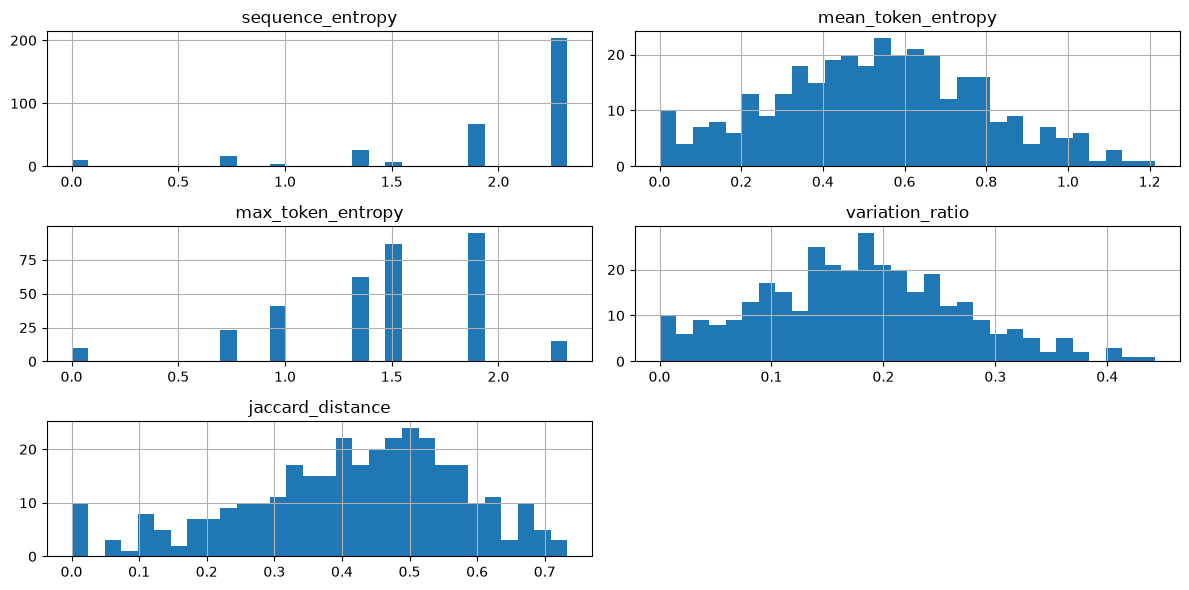

In [7]:
import matplotlib.pyplot as plt

scores.hist(bins=30, figsize=(12, 6))
plt.tight_layout()

In [8]:
metric = "mean_token_entropy"
key = scores[metric].idxmax()
rec = cache[key]
print(f"most uncertain by {metric} ({scores.loc[key, metric]:.3f}):")
pd.DataFrame(
    [rec["gt_tags"], *rec["parsed_samples"]],
    index=["gold", *[f"sample {i + 1}" for i in range(len(rec["parsed_samples"]))]],
    columns=rec["tokens"],
)

most uncertain by mean_token_entropy (1.214):


,For,each,of,these,patients,",",the,first,and,second,...,team-leader,and,the,attending,psychiatrist,formulate,a,treatment,plan,.
gold,O,O,O,O,O,O,B-Actor,I-Actor,I-Actor,I-Actor,...,I-Actor,I-Actor,I-Actor,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 1,B-Actor,I-Actor,I-Condition Specification,O,B-Actor,O,B-Activity Data,I-Activity Data,B-AND Gateway,I-Activity Data,...,I-Actor,B-AND Gateway,B-Activity Data,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 2,B-Actor,I-Actor,B-Further Specification,I-Further Specification,O,O,B-Activity Data,I-Activity Data,B-AND Gateway,I-Activity Data,...,I-Actor,B-AND Gateway,B-Activity Data,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 3,B-Actor,I-Actor,I-AND Gateway,O,B-Actor,O,B-Activity Data,I-Activity,I-Activity,I-Activity,...,B-Actor,I-Activity,B-Activity Data,B-Actor,B-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 4,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
sample 5,B-Further Specification,O,B-Actor,O,B-Actor,O,B-Activity Data,I-Further Specification,I-AND Gateway,I-Further Specification,...,B-Actor,I-AND Gateway,B-Activity Data,B-Actor,B-Actor,B-Activity,B-Further Specification,I-Activity,I-Activity Data,O


## Stage 3 — selection

At a given budget, `select` picks either a seeded random subset or the top-n most uncertain sentences (ties broken with a fixed seed so uncertainty subsets are identical across repeats). Note the mean sentence length of each subset: unnormalized metrics favor long sentences, which buys more training tokens per budget — a known confound, also reported per cell in the summary table.

In [9]:
from uq_pet.selection import select

keys = list(by_key)
n = round(len(keys) * 10 / 100)  # 10% budget

random_keys = select("random", keys, None, n, seed=0)
uncertain_keys = select("uncertainty:mean_token_entropy", keys,
                        scores["mean_token_entropy"].to_dict(), n, seed=0)

def mean_len(selected):
    return sum(len(by_key[k]["tokens"]) for k in selected) / len(selected)

print(f"10% budget -> {n} sentences")
print(f"overlap between the two subsets: {len(set(random_keys) & set(uncertain_keys))}")
print(f"mean sentence length   random: {mean_len(random_keys):.1f}   "
      f"uncertainty: {mean_len(uncertain_keys):.1f}")

10% budget -> 33 sentences
overlap between the two subsets: 5
mean sentence length   random: 18.9   uncertainty: 21.2


## Mini training demo (live, ~2 min)

One real fine-tune to show the mechanics: `distilbert-base-cased` on the 10%-budget uncertainty subset with the fixed grid recipe, evaluated on the held-out test split. This reproduces the recorded grid cell `budget=10|strategy=uncertainty:mean_token_entropy|seed=0` (entity F1 ≈ 0.60) — the only cell in this notebook that does real work on every run.

In [10]:
from uq_pet.evaluate import evaluate_model_on
from uq_pet.train import train_token_classifier

model, tokenizer = train_token_classifier([by_key[k] for k in uncertain_keys], cfg.train, seed=0)
metrics = evaluate_model_on(model, tokenizer, list(test), cfg.train)
del model
{k: v for k, v in metrics.items() if k != "per_type_f1"}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/20 loss=2.7582


  epoch 5/20 loss=1.4367


  epoch 10/20 loss=0.4711


  epoch 15/20 loss=0.1648


  epoch 20/20 loss=0.1107


{'entity_f1': 0.5975609756097561,
 'entity_precision': 0.5337690631808278,
 'entity_recall': 0.6786703601108033,
 'token_accuracy': 0.7130434782608696}

## Stage 4 — full grid (cache-aware)

The real experiment: budgets {10, 25, 50}% × strategies {random + 3 uncertainty metrics} × 5 seeds, plus a strategy-independent 100% full-pool reference per seed — 65 cells, each a full 20-epoch fine-tune + evaluation appended to `results/experiment_runs.jsonl`. Completed cells are skipped, so with the shipped run log this prints 65 skips in seconds. To actually re-run (hours), delete or trim `results/experiment_runs.jsonl`.

In [11]:
from uq_pet.experiment import run_grid

run_grid(cfg)

Grid: 65 cells (65 already recorded)
[1/65] skip (done): budget=10|strategy=random|seed=0
[2/65] skip (done): budget=10|strategy=random|seed=1
[3/65] skip (done): budget=10|strategy=random|seed=2
[4/65] skip (done): budget=10|strategy=random|seed=3
[5/65] skip (done): budget=10|strategy=random|seed=4
[6/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=0
[7/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=1
[8/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=2
[9/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=3
[10/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=4
[11/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=0
[12/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=1
[13/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=2
[14/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=3
[15/65] 

## Stage 5 — report

Summary table (entity F1 per cell, ΔF1 vs random, and the length confound column) plus the two figures, written to `results/figures/`.

In [12]:
from uq_pet.reporting import (load_runs, plot_learning_curves,
                              plot_uncertainty_vs_error, summary_table)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
runs = load_runs()
print(f"{len(runs)} recorded runs")
Markdown(summary_table(runs))

65 recorded runs


| Budget | Strategy | Entity F1 (mean±std) | ΔF1 vs random | Token acc | Mean sent. len |
|--------|----------|----------------------|---------------|-----------|----------------|
| 10% | random | 0.5732 ± 0.0119 | — | 0.7077 | 18.3 |
| 10% | uncertainty:jaccard_distance | 0.5745 ± 0.0115 | +0.0013 | 0.7065 | 20.7 |
| 10% | uncertainty:mean_token_entropy | 0.6020 ± 0.0042 | +0.0288 | 0.7133 | 21.2 |
| 10% | uncertainty:sequence_entropy | 0.6157 ± 0.0227 | +0.0425 | 0.7414 | 17.3 |
| 25% | random | 0.6967 ± 0.0165 | — | 0.7763 | 18.3 |
| 25% | uncertainty:jaccard_distance | 0.6832 ± 0.0073 | -0.0136 | 0.7920 | 21.0 |
| 25% | uncertainty:mean_token_entropy | 0.6937 ± 0.0140 | -0.0031 | 0.7933 | 21.1 |
| 25% | uncertainty:sequence_entropy | 0.7033 ± 0.0122 | +0.0065 | 0.7735 | 19.1 |
| 50% | random | 0.7429 ± 0.0106 | — | 0.8005 | 18.1 |
| 50% | uncertainty:jaccard_distance | 0.7468 ± 0.0057 | +0.0039 | 0.8148 | 21.1 |
| 50% | uncertainty:mean_token_entropy | 0.7531 ± 0.0039 | +0.0102 | 0.8171 | 20.8 |
| 50% | uncertainty:sequence_entropy | 0.7438 ± 0.0183 | +0.0009 | 0.7945 | 19.3 |
| 100% | full pool | 0.7759 ± 0.0104 | — | 0.8297 | 17.9 |

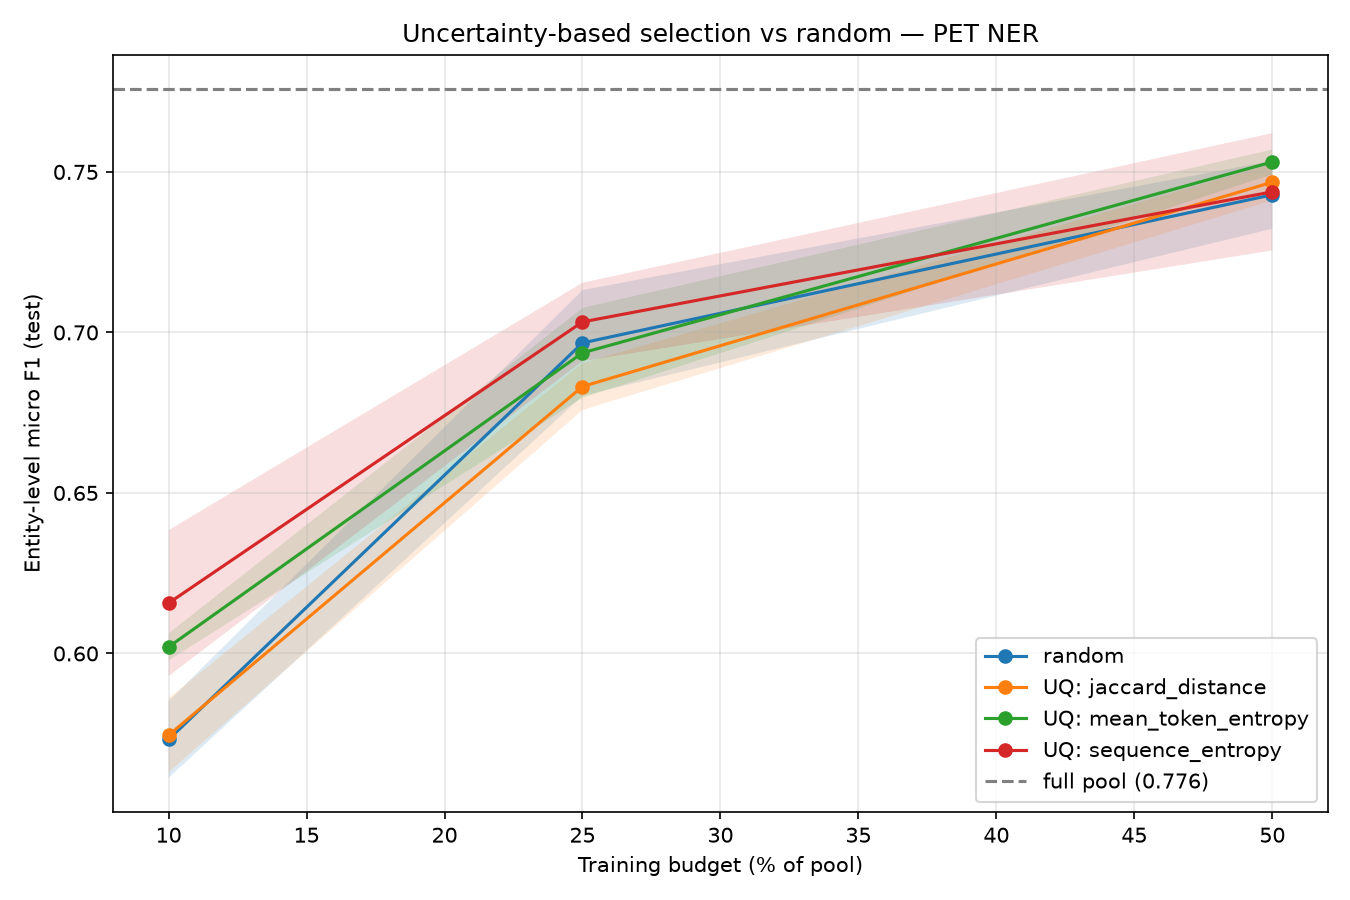

In [13]:
plot_learning_curves(runs, FIGURES_DIR / "learning_curves.png")
Image(filename=str(FIGURES_DIR / "learning_curves.png"))

Spearman(uncertainty, LLM error): {'jaccard_distance': 0.28, 'max_token_entropy': 0.201, 'mean_token_entropy': 0.279, 'sequence_entropy': 0.164, 'variation_ratio': 0.264}


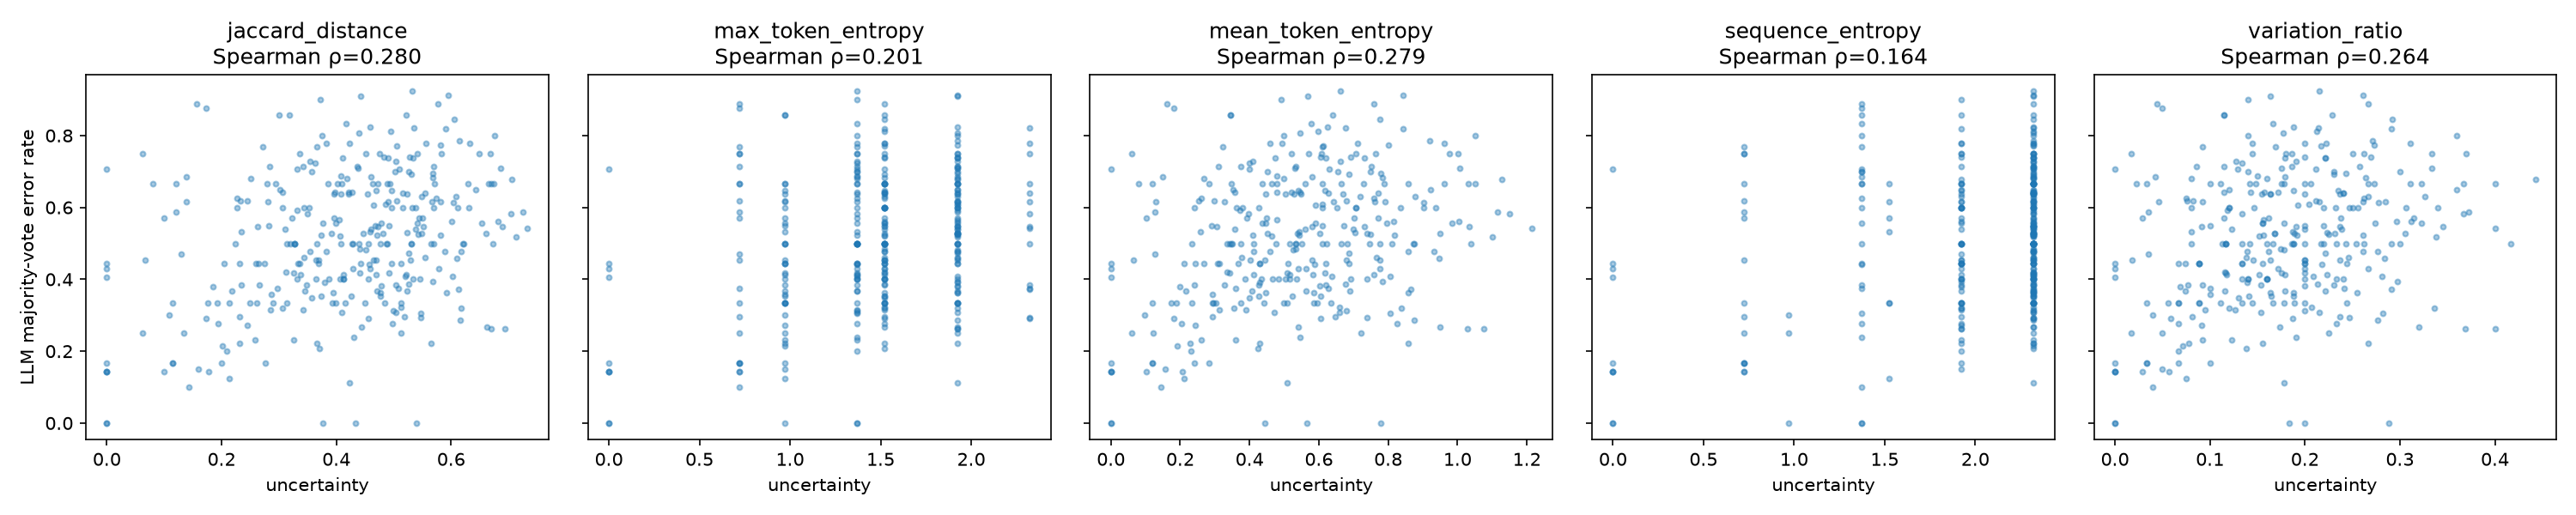

In [14]:
correlations = plot_uncertainty_vs_error(cache, FIGURES_DIR / "uncertainty_vs_error.png")
print("Spearman(uncertainty, LLM error):",
      {k: round(v, 3) for k, v in sorted(correlations.items())})
Image(filename=str(FIGURES_DIR / "uncertainty_vs_error.png"))

## Reading the results

`learning_curves.png` is the decision plot: if an uncertainty metric's F1-vs-budget curve sits above the random curve beyond the ±std bands consistently across budgets, uncertainty selection wins. Sanity-check with `uncertainty_vs_error.png` (does the metric track LLM difficulty at all?) and the mean-sentence-length column in the summary table (unnormalized metrics favor long sentences — more tokens per budget).